In [1]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
import xgboost as xgb
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from src.balance import split_data_nested_cv_ts, split_data, drop_mice_group, balance_classes_by_undersampling, balance_classes_by_undersampling_features_and_target, balance_before_merge, oversample_and_merge, ensemble_sample_and_merge

Fold 0:
Train class distribution: Counter({1: 66, 0: 12})
Validation class distribution: Counter({1: 64, 0: 12})
Test class distribution: Counter({1: 59, 0: 17})
Best parameters for fold 0: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}

Fold 0 results:
Accuracy: 0.7632
F1-macro: 0.4328
Precision-macro: 0.3867
Recall-macro: 0.4915
ROC AUC: 0.5693
PR AUC: 0.8445
True Positives: 58, False Negatives: 1, False Positives: 17, True Negatives: 0
Fold 1:
Train class distribution: Counter({1: 125, 0: 29})
Validation class distribution: Counter({1: 59, 0: 17})
Test class distribution: Counter({1: 58, 0: 18})
Best parameters for fold 1: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 1000, 'subsample': 1.0}

Fold 1 results:
Accuracy: 0.7500
F1-macro: 0.5452
Precision-macro: 0.6056
Recall-macro: 0.5489
ROC AUC: 0.7155
PR AUC: 0.8866
True Positives: 54, False Negatives: 4, False Positives: 15, True Negatives: 3
Fold 2:
Train class distribution: Counter({1: 18

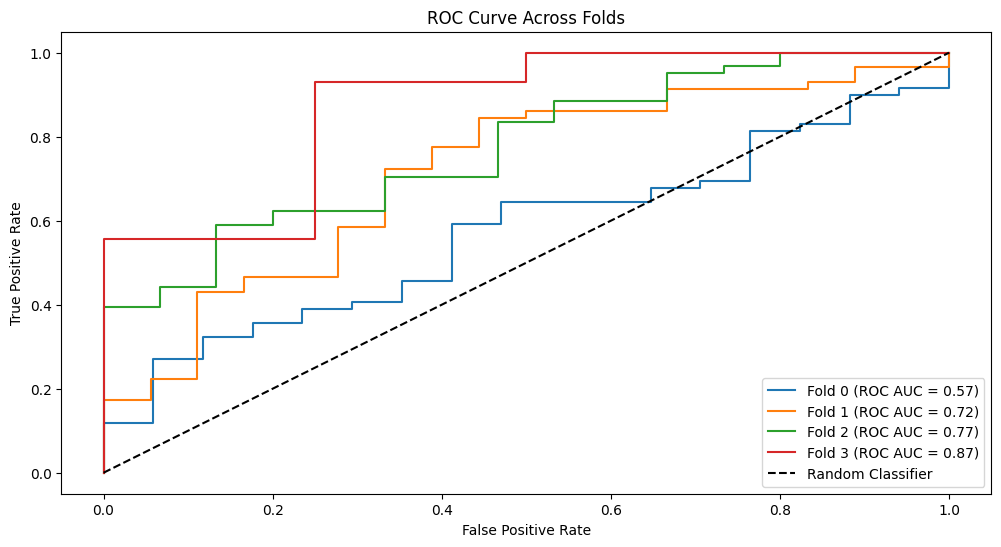

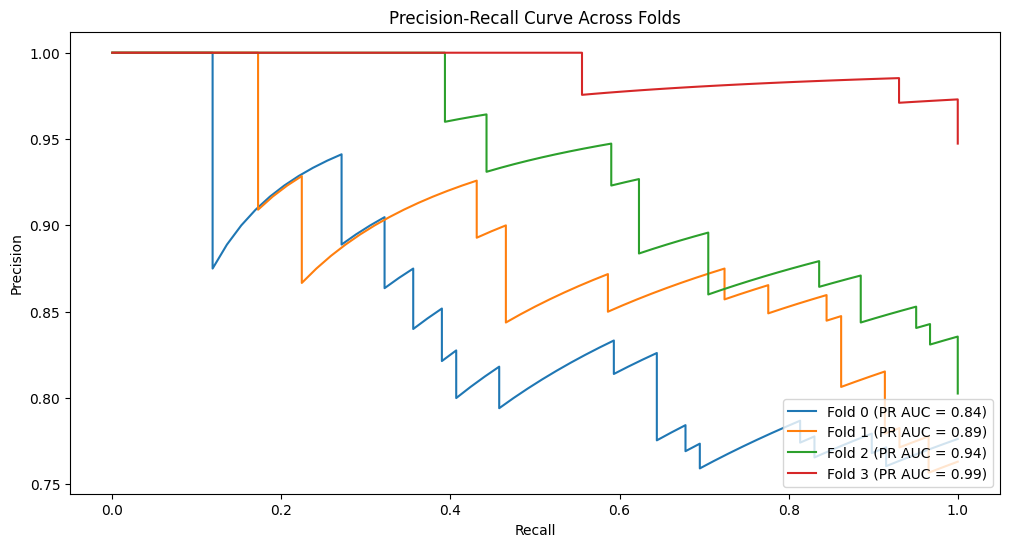


Summary Across Folds:
Mean accuracy: 0.8158
Mean F1-macro: 0.5839
Mean precision-macro: 0.6600
Mean recall-macro: 0.5833
Mean ROC AUC: 0.7325
Mean PR AUC: 0.9146


In [5]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES_NO_FILTERS, all_features=False)
dataclass.read()
df = dataclass.preprocess(remove_mice_id=False, start_col=3)  # Keep mouse ID for the later splits

# Save the preprocessed data to a file
df.to_csv('preprocessed.csv', index=False)


# Hyperparameter grid for XGBClassifier
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0]
}


from sklearn.model_selection import TimeSeriesSplit
from imblearn.over_sampling import SMOTE
from collections import Counter

def expanding_window_split_with_oversampling(df, n_splits=4):
    """
    Perform Expanding Window Split with Oversampling.

    Args:
        df (pd.DataFrame): DataFrame containing all instances, sorted by time.
        n_splits (int): Number of splits for expanding windows.

    Returns:
        splits (dict): Dictionary with train-test-validation splits for each fold.
    """
    splits = {}

    # Sort the DataFrame by 'day_of_study' to ensure chronological order
    df = df.sort_values(by='day_of_study').reset_index(drop=True)

    # TimeSeriesSplit for expanding window
    tscv = TimeSeriesSplit(n_splits=n_splits)
    for i, (train_indices, test_indices) in enumerate(tscv.split(df)):
        test_set_size = len(test_indices)
        
        # Validation indices (last part of the training set)
        val_indices = train_indices[-test_set_size:]
        
        # Prepare training, validation, and testing sets
        X_train = df.iloc[train_indices].drop(columns=['group_name', 'm_id']).reset_index(drop=True)
        y_train = df.iloc[train_indices]['group_name'].reset_index(drop=True)
        
        y_val = df.iloc[val_indices]['group_name'].reset_index(drop=True)
        
        X_test = df.iloc[test_indices].drop(columns=['group_name', 'm_id']).reset_index(drop=True)
        y_test = df.iloc[test_indices]['group_name'].reset_index(drop=True)

        # Check if training set has both classes; apply oversampling if not
        if len(y_train.unique()) < 2:
            print(f"Before oversampling, y_train distribution: {Counter(y_train)}")
            smote = SMOTE(random_state=42)
            X_train, y_train = smote.fit_resample(X_train, y_train)
            print(f"After oversampling, y_train distribution: {Counter(y_train)}")

        # Check if validation set has both classes
        if len(y_val.unique()) < 2:
            print(f"Validation set in fold {i} does not contain both classes. Consider adjusting validation strategy.")

        # Store splits
        splits[i] = {
            'X_train': X_train,
            'y_train': y_train,
            'validation_indices': val_indices,
            'y_val': y_val,
            'X_test': X_test,
            'y_test': y_test
        }
    
    return splits

# Apply expanding window split with oversampling
m_data = expanding_window_split_with_oversampling(df)

# Function to create PredefinedSplit from the cv indices
def create_predefined_split(n_samples:int, cv_indices):
    test_fold = np.full((n_samples,), -1)
    test_fold[cv_indices] = 0
    ps = PredefinedSplit(test_fold)
    return ps

from sklearn.metrics import roc_curve, precision_recall_curve

# Track results for each fold
fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls, fold_roc_aucs, fold_pr_aucs = [], [], [], [], [], []
class_metrics = {'precision_class_0': [], 'precision_class_1': [], 'recall_class_0': [], 'recall_class_1': [],
                 'f1_class_0': [], 'f1_class_1': [], 'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

# Store ROC and PR curve points for all folds
roc_curves = []
pr_curves = []

# Train and evaluate
for fold, split_data in m_data.items():

    print(f"Fold {fold}:")
    print(f"Train class distribution: {Counter(split_data['y_train'])}")
    print(f"Validation class distribution: {Counter(split_data['y_val'])}")
    print(f"Test class distribution: {Counter(split_data['y_test'])}")

    # Define PredefinedSplit
    ps = create_predefined_split(len(split_data['X_train']), split_data['validation_indices'])

    # Grid search for hyperparameter tuning
    model = xgb.XGBClassifier(random_state=42)
    grid_search = GridSearchCV(model, param_grid, scoring='f1_macro', n_jobs=-1)
    grid_search.fit(split_data['X_train'], split_data['y_train'])

    best_model = grid_search.best_estimator_
    print(f"Best parameters for fold {fold}: {grid_search.best_params_}")

    # Evaluate on the test set
    preds = best_model.predict(split_data['X_test'])
    preds_proba = best_model.predict_proba(split_data['X_test'])[:, 1]  # Probability for the positive class

    # Calculate metrics
    accuracy = accuracy_score(split_data['y_test'], preds)
    f1_macro = f1_score(split_data['y_test'], preds, average='macro')
    precision_macro = precision_score(split_data['y_test'], preds, average='macro', zero_division=0)
    recall_macro = recall_score(split_data['y_test'], preds, average='macro')
    roc_auc = roc_auc_score(split_data['y_test'], preds_proba, multi_class='ovo')
    precision, recall, _ = precision_recall_curve(split_data['y_test'], preds_proba, pos_label=1)
    pr_auc = auc(recall, precision)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(split_data['y_test'], preds).ravel()

    # Print fold results
    print(f"\nFold {fold} results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-macro: {f1_macro:.4f}")
    print(f"Precision-macro: {precision_macro:.4f}")
    print(f"Recall-macro: {recall_macro:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")
    print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}")

    # Track results
    fold_accuracies.append(accuracy)
    fold_f1_macros.append(f1_macro)
    fold_precisions.append(precision_macro)
    fold_recalls.append(recall_macro)
    fold_roc_aucs.append(roc_auc)
    fold_pr_aucs.append(pr_auc)

    class_metrics['true_positives'].append(tp)
    class_metrics['false_negatives'].append(fn)
    class_metrics['false_positives'].append(fp)
    class_metrics['true_negatives'].append(tn)

    # Store ROC and PR curve points
    fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba, pos_label=1)
    roc_curves.append((fpr, tpr))
    pr_curves.append((precision, recall))

# Plotting ROC curves
plt.figure(figsize=(12, 6))
for i, (fpr, tpr) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i} (ROC AUC = {fold_roc_aucs[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.title("ROC Curve Across Folds")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Plotting Precision-Recall curves
plt.figure(figsize=(12, 6))
for i, (precision, recall) in enumerate(pr_curves):
    plt.plot(recall, precision, label=f'Fold {i} (PR AUC = {fold_pr_aucs[i]:.2f})')
plt.title("Precision-Recall Curve Across Folds")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower right")
plt.show()

# Display summary statistics across folds
print(f"\nSummary Across Folds:")
print(f"Mean accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-macro: {np.mean(fold_f1_macros):.4f}")
print(f"Mean precision-macro: {np.mean(fold_precisions):.4f}")
print(f"Mean recall-macro: {np.mean(fold_recalls):.4f}")
print(f"Mean ROC AUC: {np.mean(fold_roc_aucs):.4f}")
print(f"Mean PR AUC: {np.mean(fold_pr_aucs):.4f}")


In [11]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES_NO_FILTERS, all_features=False)
dataclass.read()
df = dataclass.preprocess(remove_mice_id=False, start_col=3)  # Keep mouse ID for the later splits

# Save the preprocessed data to a file
# df.to_csv('preprocessed.csv', index=False)


# Hyperparameter grid for XGBClassifier
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0]
}

from imblearn.over_sampling import SMOTE
from collections import Counter

def split_data_population_informed(df, n_splits=4, test_size=np.random.uniform(0.3, 0.7)):
    """
    Perform population-informed nested cross-validation.

    Args:
        df (pd.DataFrame): The dataset with instances and metadata.
        n_splits (int): Number of splits for the outer loop.
        test_size (float): Proportion of groups used for testing.

    Returns:
        splits (dict): Dictionary containing training, validation, and test sets.
    """
    splits = {}
    group_ids = df['m_id'].unique()
    total_groups = len(group_ids)
    test_groups_count = max(1, int(total_groups * test_size))

    print(f"Total groups: {total_groups}, Test groups: {test_groups_count}")

    # Outer loop to vary test and validation groups
    for i in range(n_splits):
        # Randomly select test groups
        test_ids = np.random.choice(group_ids, test_groups_count, replace=False)

        # Separate data into test, validation, and training groups
        test_group = df[df['m_id'].isin(test_ids)].sort_values(by='day_of_study').reset_index(drop=True)
        train_group = df[~df['m_id'].isin(test_group)].reset_index(drop=True)

        # Define train and test indices for the test group
        train_indices = list(range(0, int(len(test_group) * 0.60)))  # First 60% for training
        test_indices = list(range(int(len(test_group) * 0.60), len(test_group)))  # Remaining 40% for testing

        test_set_size = len(test_indices)

        # Validation indices (last `test_set_size` samples of the training group)
        val_indices = train_indices[-test_set_size:]

        # Prepare training, validation, and testing sets
        X_train = pd.concat([train_group.drop(columns=['m_id', 'group_name']),
                             test_group.iloc[train_indices].drop(columns=['m_id', 'group_name'])]).reset_index(drop=True)
        y_train = pd.concat([train_group['group_name'], test_group.iloc[train_indices]['group_name']]).reset_index(drop=True)

        X_test = test_group.iloc[test_indices].drop(columns=['m_id', 'group_name']).reset_index(drop=True)
        y_test = test_group.iloc[test_indices]['group_name'].reset_index(drop=True)

        # Validation indices relative to `X_train` and `y_train`
        cv_indices = [i + len(train_group) for i in val_indices]
        y_val = y_train.iloc[cv_indices]

        print(f'Fold {i}')
        print(f'Train indices: {list(range(len(train_group)))}')
        print(f'Test indices: {test_indices}')
        print(f'Validation indices: {cv_indices}')

        # Check if training set has both classes; apply oversampling if not
        if len(y_train.unique()) < 2:
            print(f"Before oversampling, y_train distribution: {Counter(y_train)}")
            smote = SMOTE(random_state=42)
            X_train, y_train = smote.fit_resample(X_train, y_train)
            print(f"After oversampling, y_train distribution: {Counter(y_train)}")

        # Check if validation set has both classes
        if len(y_val.unique()) < 2:
            print(f"Validation set in fold {i} does not contain both classes. Adjusting strategy may be necessary.")

        # Store splits
        splits[i] = {
            'X_train': X_train,
            'y_train': y_train,
            'cv_indices': cv_indices,
            'X_test': X_test,
            'y_test': y_test
        }

    return splits

# Run nested cross-validation with multiple groups for test and validation
m_data = split_data_population_informed(df)

# Function to create PredefinedSplit from the cv indices
def create_predefined_split(n_samples:int, cv_indices):
    test_fold = np.full((n_samples,), -1)
    test_fold[cv_indices] = 0
    ps = PredefinedSplit(test_fold)
    return ps


# Additional imports
from sklearn.metrics import roc_curve, precision_recall_curve

# Track results for each fold
fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls, fold_roc_aucs, fold_pr_aucs = [], [], [], [], [], []
roc_curves = []  # Store ROC curve points
pr_curves = []   # Store Precision-Recall curve points

# Train and evaluate
for fold, split_data in m_data.items():
    # Define PredefinedSplit using the cv indices from the split_data
    ps = create_predefined_split(len(split_data['X_train']), split_data['cv_indices'])

    # Grid search for hyperparameter tuning
    model = xgb.XGBClassifier(random_state=42)
    grid_search = GridSearchCV(model, param_grid, cv=ps, scoring='f1_macro', n_jobs=-1)
    grid_search.fit(split_data['X_train'], split_data['y_train'])

    best_model = grid_search.best_estimator_
    print(f"Best parameters for fold {fold}: {grid_search.best_params_}")

    # Evaluate on the test set
    preds = best_model.predict(split_data['X_test'])
    preds_proba = best_model.predict_proba(split_data['X_test'])[:, 1]  # Probability for the positive class

    # Calculate metrics
    accuracy = accuracy_score(split_data['y_test'], preds)
    f1_macro = f1_score(split_data['y_test'], preds, average='macro')
    precision_macro = precision_score(split_data['y_test'], preds, average='macro', zero_division=0)
    recall_macro = recall_score(split_data['y_test'], preds, average='macro')
    roc_auc = roc_auc_score(split_data['y_test'], preds_proba)
    precision, recall, _ = precision_recall_curve(split_data['y_test'], preds_proba, pos_label=1)
    pr_auc = auc(recall, precision)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(split_data['y_test'], preds).ravel()

    # Print fold results
    print(f"\nFold {fold} results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-macro: {f1_macro:.4f}")
    print(f"Precision-macro: {precision_macro:.4f}")
    print(f"Recall-macro: {recall_macro:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")
    print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}")

    # Track metrics for all folds
    fold_accuracies.append(accuracy)
    fold_f1_macros.append(f1_macro)
    fold_precisions.append(precision_macro)
    fold_recalls.append(recall_macro)
    fold_roc_aucs.append(roc_auc)
    fold_pr_aucs.append(pr_auc)

    # Store ROC and PR curve points
    fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba, pos_label=1)
    roc_curves.append((fpr, tpr))
    pr_curves.append((precision, recall))

# Plotting ROC curves
plt.figure(figsize=(10, 6))
for i, (fpr, tpr) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i} (ROC AUC = {fold_roc_aucs[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.title("ROC Curve Across Folds")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Plotting Precision-Recall curves
plt.figure(figsize=(10, 6))
for i, (precision, recall) in enumerate(pr_curves):
    plt.plot(recall, precision, label=f'Fold {i} (PR AUC = {fold_pr_aucs[i]:.2f})')
plt.title("Precision-Recall Curve Across Folds")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower right")
plt.show()

# Display summary statistics across folds
print("\nSummary Across Folds:")
print(f"Mean accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-macro: {np.mean(fold_f1_macros):.4f}")
print(f"Mean Precision-macro: {np.mean(fold_precisions):.4f}")
print(f"Mean Recall-macro: {np.mean(fold_recalls):.4f}")
print(f"Mean ROC AUC: {np.mean(fold_roc_aucs):.4f}")
print(f"Mean PR AUC: {np.mean(fold_pr_aucs):.4f}")




Total groups: 18, Test groups: 10
Fold 0
Train indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210

ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.

Performing nested cross-validation with 6 inner splits and test size of 0.2
Training on fold 0 with 130 samples
Best parameters for fold 0: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}
Training on fold 1 with 168 samples
Best parameters for fold 1: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.7}
Training on fold 2 with 210 samples
Best parameters for fold 2: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}
Training on fold 3 with 252 samples
Best parameters for fold 3: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 1.0}
Training on fold 4 with 294 samples
Best parameters for fold 4: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 1.0}
Training on fold 5 with 336 samples
Best parameters for fold 5: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'subsample': 1.0}

Mean accuracy across folds: 0.8532
Mean F1-macro across folds: 0

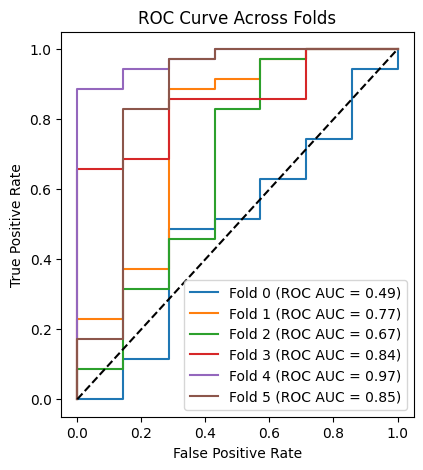

In [ ]:
from ngboost import NGBClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES_NO_FILTERS, all_features=False)
dataclass.read()
df = dataclass.preprocess(remove_mice_id=False, start_col=3)  # Keep mouse ID for the later splits

# Save the preprocessed data to a file
df.to_csv('preprocessed.csv', index=False)

# Leave only 3 columns for testing purposes
# df = df.iloc[:, :3]

# Hyperparameter grid for XGBClassifier
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0]
}

# Define the outer cross-validation settings
n_splits = 6
test_size = 0.2

# Initialize result storage
fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls = [], [], [], []
class_metrics = {'precision_class_0': [], 'precision_class_1': [], 'recall_class_0': [], 'recall_class_1': [],
                 'f1_class_0': [], 'f1_class_1': [], 'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

# Nested cross-validation split function
def split_data_nested_cv_ts(df, n_splits=n_splits, test_size=test_size):
    print(f"Performing nested cross-validation with {n_splits} inner splits and test size of {test_size}")
    splits = {}
    # il = 0
    for _, group in df.groupby('m_id'):
        # print(f"Processing mouse {m_id}")
        # if il == 2:
        #     break
        group = group.sort_values(by='day_of_study').reset_index(drop=True)
        # print(f"Group: {group}")

        if len(group) < n_splits + 1:
            # print(f"Adding mouse {group['m_id'].iloc[0]} to train set due to insufficient data")
            split_idx = 0
            if split_idx not in splits:
                # print("Don't know why this is happening")
                X_train, y_train = group.drop(columns=['m_id', 'group_name']), group['group_name']
                # print('heeeu', [(list(range(len(X_train))), list())])
                splits[split_idx] = {
                    'X_train': X_train,
                    'y_train': y_train,
                    'train_cv_split': [(list(range(len(X_train))), list())],
                    'X_test': None,
                    'y_test': None
                }
            else:
                if splits[split_idx]['X_train'] is None and splits[split_idx]['y_train'] is None:
                    # print('Empty')
                    # print("Don't know why this is happening")
                    X_train, y_train = group.drop(columns=['m_id', 'group_name']), group['group_name']
                    splits[split_idx]['X_train'] = X_train
                    splits[split_idx]['y_train'] = y_train
                    splits[split_idx]['train_cv_split'] = [(list(range(len(X_train))), list())]
                else:
                    # print('Not empty')
                    X_train, y_train = group.drop(columns=['m_id', 'group_name']), group['group_name']
                    splits[split_idx]['X_train'] = pd.concat([splits[split_idx]['X_train'], X_train], axis=0, ignore_index=True)
                    splits[split_idx]['y_train'] = pd.concat([splits[split_idx]['y_train'], y_train], axis=0, ignore_index=True)
                    # Print new train_cv_split
                    # print([(list(range(len(X_train))), list())])
                    # print('new train_cv_split', [i + len(splits[split_idx]['X_train']) for i in list(range(len(X_train)))])
                    splits[split_idx]['train_cv_split'][0][0].extend([i + len(splits[split_idx]['X_train']) for i in list(range(len(X_train)))])
            continue

        tscv = TimeSeriesSplit(n_splits=n_splits + 1).split(group)  # Inner CV for tuning
        next(tscv)  # Skip the first split

        for split_idx, (train_cv_indices, test_indices) in enumerate(tscv):
            X_train, y_train = group.iloc[train_cv_indices].drop(columns=['m_id', 'group_name']), group.iloc[train_cv_indices]['group_name']
            X_test, y_test = group.iloc[test_indices].drop(columns=['m_id', 'group_name']), group.iloc[test_indices]['group_name']

            test_len = len(X_test)
            train_cv_split = [(list(range(train_cv_indices[0],train_cv_indices[-test_len])), list(range(train_cv_indices[-test_len],train_cv_indices[-1]+1)))]
            # print(f"train_cv_split: {train_cv_split}")
            # Mostrar los valores de '10Percentile' para cada conjunto
            # print("Training:", X_train['10Percentile'].iloc[0], "--", X_train['10Percentile'].iloc[-test_len-1],
            #     ", CV:", X_train['10Percentile'].iloc[-test_len], "--", X_train['10Percentile'].iloc[-1],
            #     ", Test:", X_test['10Percentile'].iloc[0], "--", X_test['10Percentile'].iloc[-1])

            if split_idx not in splits:
                splits[split_idx] = {
                    'X_train': X_train,
                    'y_train': y_train,
                    'train_cv_split': train_cv_split,
                    'X_test': X_test,
                    'y_test': y_test
                }
            else:
                #print(splits[split_idx]['train_cv_split'])
                # To add new train and cv indices we have to take into account the previous instance indices
                splits[split_idx]['train_cv_split'][0][0].extend([i + len(splits[split_idx]['X_train']) for i in train_cv_split[0][0]])
                splits[split_idx]['train_cv_split'][0][1].extend([i + len(splits[split_idx]['X_train']) for i in train_cv_split[0][1]])
                # To add new train and cv indices we have to take into account the previous instance indices
                #splits[split_idx]['train_cv_split'].append()

                splits[split_idx]['X_train'] = pd.concat([splits[split_idx]['X_train'], X_train], axis=0, ignore_index=True)
                splits[split_idx]['y_train'] = pd.concat([splits[split_idx]['y_train'], y_train], axis=0, ignore_index=True)
                splits[split_idx]['X_test'] = pd.concat([splits[split_idx]['X_test'], X_test], axis=0, ignore_index=True)
                splits[split_idx]['y_test'] = pd.concat([splits[split_idx]['y_test'], y_test], axis=0, ignore_index=True)

        #  il += 1

    return splits

# Perform nested cross-validation
plt.figure(figsize=(10, 5))
m_data = split_data_nested_cv_ts(df)

X_train_all = []
y_train_all = []
X_test_all = []
y_test_all = []
#print(f"m_data: {m_data}")

# Add m_data dict to a txt file
with open('m_data.txt', 'w') as f:
    print(m_data, file=f)

# Function to create PredefinedSplit from 'train_cv_split'
def create_predefined_split(all_data_len: int, cv_indices):
    cv_fold = np.full((all_data_len,), -1)
    cv_fold[cv_indices] = 0  # Mark CV fold indices
    # print(f"cv_fold: {cv_fold}")
    # PredefinedSplit uses -1 for training and 0 for validation
    return PredefinedSplit(test_fold=cv_fold)

for split_idx, split_data in m_data.items():

    # Create PredefinedSplit using the cv indices from the split_data
    ps = create_predefined_split(len(split_data['X_train']), split_data['train_cv_split'][0][1])

    # Inner loop: Hyperparameter tuning with GridSearchCV
    model = xgb.XGBClassifier(random_state=42)
    grid_search = GridSearchCV(model, param_grid, cv=ps, scoring='f1_macro', n_jobs=-1)
    print(f"Training on fold {split_idx} with {len(split_data['X_train'])} samples")
    grid_search.fit(split_data['X_train'], split_data['y_train'])

    best_model = grid_search.best_estimator_
    print(f"Best parameters for fold {split_idx}: {grid_search.best_params_}")

    # Evaluate on the outer test set
    preds = best_model.predict(split_data['X_test'])
    preds_proba = best_model.predict_proba(split_data['X_test'])[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(split_data['y_test'], preds)
    f1_macro = f1_score(split_data['y_test'], preds, average='macro')
    precision_macro = precision_score(split_data['y_test'], preds, average='macro', zero_division=0)
    recall_macro = recall_score(split_data['y_test'], preds, average='macro')
    roc_auc = roc_auc_score(split_data['y_test'], preds_proba)
    precision, recall, _ = precision_recall_curve(split_data['y_test'], preds_proba)
    pr_auc = auc(recall, precision)

    # Track results
    fold_accuracies.append(accuracy)
    fold_f1_macros.append(f1_macro)
    fold_precisions.append(precision_macro)
    fold_recalls.append(recall_macro)

    # Confusion matrix metrics
    tn, fp, fn, tp = confusion_matrix(split_data['y_test'], preds).ravel()
    class_metrics['true_positives'].append(tp)
    class_metrics['false_negatives'].append(fn)
    class_metrics['false_positives'].append(fp)
    class_metrics['true_negatives'].append(tn)

    # Plotting
    fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba)
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'Fold {split_idx} (ROC AUC = {roc_auc:.2f})')

# ROC Curve formatting
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Across Folds")
plt.legend(loc="lower right")


# Display summary statistics across folds
print(f"\nMean accuracy across folds: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-macro across folds: {np.mean(fold_f1_macros):.4f}")
print(f"Mean precision-macro across folds: {np.mean(fold_precisions):.4f}")
print(f"Mean recall-macro across folds: {np.mean(fold_recalls):.4f}")

In [ ]:
from ngboost import NGBClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FEATURES_3_GROUPS)
dataclass.read()
df = dataclass.preprocess(remove_mice_id=False, start_col=3)  # Keep mouse ID for the later splits

# Leave only 9 rows and 3 columns for testing purposes
df = df.iloc[:9, :3]

# Hyperparameter grid for XGBClassifier
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0]
}

# Define the outer cross-validation settings
n_splits = 3
test_size = 0.2

# Initialize result storage
fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls = [], [], [], []
class_metrics = {'precision_class_0': [], 'precision_class_1': [], 'recall_class_0': [], 'recall_class_1': [],
                 'f1_class_0': [], 'f1_class_1': [], 'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

# Nested cross-validation split function
def split_data_nested_cv_ts(df, n_splits=n_splits, test_size=test_size):
    print(f"Performing nested cross-validation with {n_splits} inner splits and test size of {test_size}")
    splits = {}
    il = 0
    for m_id, group in df.groupby('m_id'):
        if i l == 1:
            break
        group = group.sort_values(by='day_of_study').reset_index(drop=True)

        if len(group) < n_splits + 1:
            print(f"Adding mouse {group['m_id'].iloc[0]} to train set due to insufficient data")
            if m_id not in splits:
                print('heeeu', [(list(range(len(X_train))), list())])
                splits[m_id] = {
                    'X_train': group.drop(columns=['m_id', 'group_name']),
                    'y_train': group['group_name'],
                    'train_cv_split': [(list(range(len(X_train))), list())],
                    'X_test': None,
                    'y_test': None
                }
            else:
                print("Don't know why this is happening")
                if splits[m_id]['X_train'] is None and splits[m_id]['y_train'] is None:
                    print('Empty')
                    splits[m_id]['X_train'] = group.drop(columns=['m_id', 'group_name'])
                    splits[m_id]['y_train'] = group['group_name']
                else:
                    print('Not empty')
                    X_train, y_train = group.drop(columns=['m_id', 'group_name']), group['group_name']
                    splits[m_id]['X_train'] = pd.concat([splits[m_id]['X_train'], X_train], axis=0)
                    splits[m_id]['y_train'] = pd.concat([splits[m_id]['y_train'], y_train], axis=0)
                    splits[m_id]['train_cv_split'].append((list(range(len(X_train))), list()))
            continue

        tscv = TimeSeriesSplit(n_splits=n_splits + 1).split(group)  # Inner CV for tuning
        next(tscv)  # Skip the first split

        for split_idx, (train_cv_indices, test_indices) in enumerate(tscv):
            X_train, y_train = group.iloc[train_cv_indices].drop(columns=['m_id', 'group_name']), group.iloc[train_cv_indices]['group_name']
            X_test, y_test = group.iloc[test_indices].drop(columns=['m_id', 'group_name']), group.iloc[test_indices]['group_name']

            test_len = len(X_test)
            train_cv_split = [(list(range(train_cv_indices[0],train_cv_indices[-test_len])), list(range(train_cv_indices[-test_len],train_cv_indices[-1]+1)))]
            # print(f"train_cv_split: {train_cv_split}")
            # Mostrar los valores de '10Percentile' para cada conjunto
            # print("Training:", X_train['10Percentile'].iloc[0], "--", X_train['10Percentile'].iloc[-test_len-1],
            #     ", CV:", X_train['10Percentile'].iloc[-test_len], "--", X_train['10Percentile'].iloc[-1],
            #     ", Test:", X_test['10Percentile'].iloc[0], "--", X_test['10Percentile'].iloc[-1])

            if m_id not in splits:
                splits[m_id] = {
                    'split_idx': split_idx,
                    'X_train': X_train,
                    'y_train': y_train,
                    'train_cv_split': train_cv_split,
                    'X_test': X_test,
                    'y_test': y_test
                }
            else:
                #print(splits[split_idx]['train_cv_split'])
                # To add new train and cv indices we have to take into account the previous instance indices
                # splits[m_id]['train_cv_split'][0][0].extend([i + len(splits[m_id]['X_train']) for i in train_cv_split[0][0]])
                # splits[m_id]['train_cv_split'][0][1].extend([i + len(splits[m_id]['X_train']) for i in train_cv_split[0][1]])
                splits[m_id]['train_cv_split'].append(train_cv_split)[0]

                splits[m_id]['X_train'] = pd.concat([splits[m_id]['X_train'], X_train], axis=0)
                splits[m_id]['y_train'] = pd.concat([splits[m_id]['y_train'], y_train], axis=0)
                splits[m_id]['X_test'] = pd.concat([splits[m_id]['X_test'], X_test], axis=0)
                splits[m_id]['y_test'] = pd.concat([splits[m_id]['y_test'], y_test], axis=0)

            # Print date ranges for each split as a verification step
            # print(f"Mouse {mouse_id}:")
            # print(f"  Train: {X_train['day_of_study'].min()} -- {X_train['day_of_study'].max()}")
            # print(f"Train number of samples: {len(X_train)}")
            # print(f"  CV: {X_test['day_of_study'].min()} -- {X_test['day_of_study'].max()}")
            # print(f"CV number of samples: {len(X_test)}")
            # print(f"  Test: {X_test['day_of_study'].min()} -- {X_test['day_of_study'].max()}")
            # print(f"Test number of samples: {len(X_test)}")
            # print("=" * 50)
        il += 1

    return splits

# Perform nested cross-validation
plt.figure(figsize=(10, 5))
m_data = split_data_nested_cv_ts(df)

X_train_all = []
y_train_all = []
X_test_all = []
y_test_all = []
#print(f"m_data: {m_data}")

# Add m_data dict to a csv file
df_m_data = pd.DataFrame(m_data)
df_m_data.to_csv('m_data.csv')

for m_id, split_data in m_data.items():
    print(f"Mouse {m_id}, split {split_data['split_idx']}")
    
    # # Inner loop: Hyperparameter tuning with GridSearchCV
    # model = xgb.XGBClassifier(random_state=42)
    # grid_search = GridSearchCV(model, param_grid, cv=TimeSeriesSplit(n_splits=split_data['train_cv_split']), scoring='roc_auc', n_jobs=-1)
    # print(f"Training on fold {split_idx} with {len(split_data['X_train'])} samples")
    # print(f'split_data_X_train: {split_data["X_train"]} \n split_data_y_train: {split_data["y_train"]}')
    # grid_search.fit(split_data['X_train'], split_data['y_train'])

    # best_model = grid_search.best_estimator_
    # print(f"Best parameters for fold {split_idx}: {grid_search.best_params_}")

    # # # Evaluate on the outer test set
    # preds = best_model.predict(split_data['X_test'])
    # preds_proba = best_model.predict_proba(split_data['X_test'])[:, 1]

    # # # Calculate metrics
    # accuracy = accuracy_score(split_data['y_test'], preds)
    # f1_macro = f1_score(split_data['y_test'], preds, average='macro')
    # precision_macro = precision_score(split_data['y_test'], preds, average='macro')
    # recall_macro = recall_score(split_data['y_test'], preds, average='macro')
    # roc_auc = roc_auc_score(split_data['y_test'], preds_proba)
    # precision, recall, _ = precision_recall_curve(split_data['y_test'], preds_proba)
    # pr_auc = auc(recall, precision)

    # # Track results
    # fold_accuracies.append(accuracy)
    # fold_f1_macros.append(f1_macro)
    # fold_precisions.append(precision_macro)
    # fold_recalls.append(recall_macro)

    # # Confusion matrix metrics
    # tn, fp, fn, tp = confusion_matrix(split_data['y_test'], preds).ravel()
    # class_metrics['true_positives'].append(tp)
    # class_metrics['false_negatives'].append(fn)
    # class_metrics['false_positives'].append(fp)
    # class_metrics['true_negatives'].append(tn)

    # # Plotting
    # fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba)
    # plt.subplot(1, 2, 1)
    # plt.plot(fpr, tpr, label=f'Fold {split_idx} (ROC AUC = {roc_auc:.2f})')
    # plt.subplot(1, 2, 2)
    # plt.plot(recall, precision, label=f'Fold {split_idx} (PR AUC = {pr_auc:.2f})')

# ROC Curve formatting
# plt.subplot(1, 2, 1)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve Across Folds")
# plt.legend(loc="lower right")

# # PR Curve formatting
# plt.subplot(1, 2, 2)
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.title("Precision-Recall Curve Across Folds")
# plt.legend(loc="lower left")
# plt.tight_layout()
# plt.show()

# # Display summary statistics across folds
# print(f"\nMean accuracy across folds: {np.mean(fold_accuracies):.4f}")
# print(f"Mean F1-macro across folds: {np.mean(fold_f1_macros):.4f}")
# print(f"Mean precision-macro across folds: {np.mean(fold_precisions):.4f}")
# print(f"Mean recall-macro across folds: {np.mean(fold_recalls):.4f}")

Performing nested cross-validation with 3 inner splits and test size of 0.2


TypeError: 'NoneType' object is not subscriptable

<Figure size 1000x500 with 0 Axes>

In [ ]:
from ngboost import NGBClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FEATURES_3_GROUPS)
dataclass.read()
df = dataclass.preprocess(remove_mice_id=False, start_col=3)  # Keep mouse ID for later splits

# Hyperparameter grid for XGBClassifier
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0]
}

# Define cross-validation settings
outer_splits = 5
inner_splits_n = 3
test_size = 0.2

# Store results for outer folds
fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls = [], [], [], []
class_metrics = {'precision_class_0': [], 'precision_class_1': [], 'recall_class_0': [], 'recall_class_1': [],
                 'f1_class_0': [], 'f1_class_1': [], 'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

# Nested cross-validation function with aggregated splits
def aggregate_data_for_nested_cv(df, test_size=test_size):
    outer_splits = []
    for mouse_id, group in df.groupby('m_id'):
        group = group.sort_values(by='day_of_study').reset_index(drop=True)
        test_len = int(len(group) * test_size)
        
        if test_len == 0:
            continue
        
        # Outer split - Test set for this mouse
        X_test = group.iloc[-test_len:].drop(columns=['m_id', 'group_name'])
        y_test = group.iloc[-test_len:]['group_name']

        # Inner splits for TimeSeries validation
        train_data = group.iloc[:-test_len]
        tscv = TimeSeriesSplit(n_splits=inner_splits_n + 1)
        
        inner_splits = []
        for train_indices, cv_indices in list(tscv.split(train_data))[1:]:
            X_train = train_data.iloc[train_indices].drop(columns=['m_id', 'group_name'])
            y_train = train_data.iloc[train_indices]['group_name']
            X_cv = train_data.iloc[cv_indices].drop(columns=['m_id', 'group_name'])
            y_cv = train_data.iloc[cv_indices]['group_name']
            
            inner_splits.append({
                'X_train': X_train,
                'y_train': y_train,
                'X_cv': X_cv,
                'y_cv': y_cv
            })
            
        outer_splits.append({
            'mouse_id': mouse_id,
            'inner_splits': inner_splits,
            'X_test': X_test,
            'y_test': y_test
        })
        
    return outer_splits

# Split the data
outer_splits = aggregate_data_for_nested_cv(df)

# Perform nested cross-validation
plt.figure(figsize=(10, 5))

for outer_idx, outer_split in enumerate(outer_splits):
    # Aggregate all inner training and validation sets across all mice for this fold
    X_train_all = []
    for inner_split in outer_split['inner_splits']:
        X_train_all.append(inner_split['X_train'])
    print(X_train_all)
    X_train_all = pd.concat(X_train_all, axis=0)
    print(X_train_all)
    X_train_all = pd.concat([split['X_train'] for inner_split in outer_split['inner_splits'] for split in inner_split], axis=0)
    y_train_all = pd.concat([split['y_train'] for inner_split in outer_split['inner_splits'] for split in inner_split], axis=0)
    X_cv_all = pd.concat([split['X_cv'] for inner_split in outer_split['inner_splits'] for split in inner_split], axis=0)
    y_cv_all = pd.concat([split['y_cv'] for inner_split in outer_split['inner_splits'] for split in inner_split], axis=0)
    X_test = outer_split['X_test']
    y_test = outer_split['y_test']

    # Inner loop: Hyperparameter tuning
    model = xgb.XGBClassifier(random_state=42)
    grid_search = GridSearchCV(model, param_grid, cv=TimeSeriesSplit(n_splits=inner_splits_n), scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train_all, y_train_all)
    best_model = grid_search.best_estimator_

    # Evaluate on the outer test set
    preds = best_model.predict(X_test)
    preds_proba = best_model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    precision_macro = precision_score(y_test, preds, average='macro')
    recall_macro = recall_score(y_test, preds, average='macro')
    roc_auc = roc_auc_score(y_test, preds_proba)
    precision, recall, _ = precision_recall_curve(y_test, preds_proba)
    pr_auc = auc(recall, precision)

    # Track results
    fold_accuracies.append(accuracy)
    fold_f1_macros.append(f1_macro)
    fold_precisions.append(precision_macro)
    fold_recalls.append(recall_macro)

    # Confusion matrix metrics
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    class_metrics['true_positives'].append(tp)
    class_metrics['false_negatives'].append(fn)
    class_metrics['false_positives'].append(fp)
    class_metrics['true_negatives'].append(tn)

    # Plotting
    fpr, tpr, _ = roc_curve(y_test, preds_proba)
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'Fold {outer_idx} (ROC AUC = {roc_auc:.2f})')
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label=f'Fold {outer_idx} (PR AUC = {pr_auc:.2f})')

# ROC Curve formatting
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Across Folds")
plt.legend(loc="lower right")

# PR Curve formatting
plt.subplot(1, 2, 2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Across Folds")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# Display summary statistics across folds
print(f"\nMean accuracy across folds: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-macro across folds: {np.mean(fold_f1_macros):.4f}")
print(f"Mean precision-macro across folds: {np.mean(fold_precisions):.4f}")
print(f"Mean recall-macro across folds: {np.mean(fold_recalls):.4f}")


{'X_train':    day_of_study  10Percentile  90Percentile    Energy  Entropy  \
0             7      0.003953      0.464455  0.095575      0.0   
1             7      0.007905      0.388626  0.079843      0.0   
2            14      0.000000      0.090047  0.021326      0.0   
3            18      0.430830      0.582938  0.001907      0.0   
4            20      0.415020      0.440758  0.001211      0.0   

   InterquartileRange  Kurtosis   Maximum  MeanAbsoluteDeviation      Mean  \
0            0.775087  0.198650  1.000000               0.892922  0.133965   
1            0.719723  0.207671  1.000000               0.785324  0.125360   
2            0.369089  0.274534  1.000000               0.396839  0.028098   
3            0.334487  0.101691  0.615385               0.327987  0.505813   
4            0.147636  0.128951  0.495192               0.163103  0.432107   

   ...  DependenceNonUniformityNormalized  DependenceVariance  \
0  ...                           0.997949            0.00

TypeError: string indices must be integers, not 'str'

<Figure size 1000x500 with 0 Axes>

Train size percentage: 87.70%
Test size percentage: 12.30%
Fold accuracy: 0.9362, F1-macro: 0.8810, Precision-macro: 0.9634, Recall-macro: 0.8333
Class 0 - Precision: 1.0000, Recall: 0.6667, F1: 0.8000
Class 1 - Precision: 0.9268, Recall: 1.0000, F1: 0.9620

ROC AUC: 0.9825, PR AUC: 0.9957
True Positives: 38, False Negatives: 0, False Positives: 3, True Negatives: 6

Train size percentage: 77.75%
Test size percentage: 22.25%
Fold accuracy: 0.9294, F1-macro: 0.8638, Precision-macro: 0.9600, Recall-macro: 0.8125
Class 0 - Precision: 1.0000, Recall: 0.6250, F1: 0.7692
Class 1 - Precision: 0.9200, Recall: 1.0000, F1: 0.9583

ROC AUC: 0.9846, PR AUC: 0.9964
True Positives: 69, False Negatives: 0, False Positives: 6, True Negatives: 10

Train size percentage: 68.06%
Test size percentage: 31.94%
Fold accuracy: 0.9180, F1-macro: 0.8371, Precision-macro: 0.9541, Recall-macro: 0.7826
Class 0 - Precision: 1.0000, Recall: 0.5652, F1: 0.7222
Class 1 - Precision: 0.9083, Recall: 1.0000, F1: 0.9519



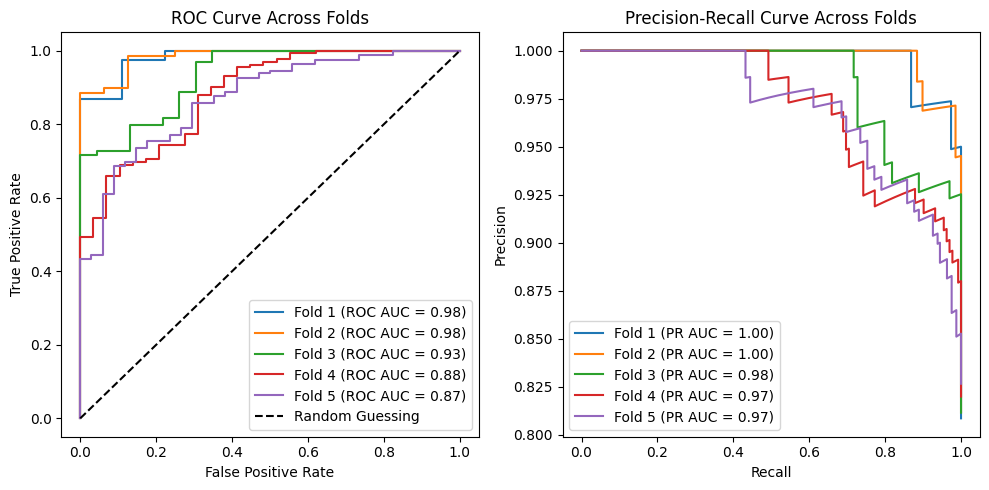


Mean accuracy across folds: 0.9078
Mean F1-macro across folds: 0.8112
Mean precision-macro across folds: 0.9150
Mean recall-macro across folds: 0.7638

Class 0 - Mean Precision: 0.9246, Mean Recall: 0.5365, Mean F1: 0.6763
Class 1 - Mean Precision: 0.9053, Mean Recall: 0.9911, Mean F1: 0.9462


: 

In [ ]:
from ngboost import NGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FEATURES_3_GROUPS)
dataclass.read()
df = dataclass.preprocess(remove_mice_id=False, start_col=3) # Keep mouse ID for the later splits

# Step 3: Create the NGBClassifier model (or XGBoost model)
model = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    random_state=42,
)

n_splits = 5

# Store results for each fold
fold_accuracies = []
fold_f1_macros = []
fold_precisions = []
fold_recalls = []
class_metrics = {'precision_class_0': [], 'precision_class_1': [],
                 'recall_class_0': [], 'recall_class_1': [],
                 'f1_class_0': [], 'f1_class_1': [], 'true_positives': [],
                 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

# Step 4: Perform TimeSeriesSplit Cross-Validation
plt.figure(figsize=(10, 5))  # Set figure size for both curves
for i in range(n_splits):
    # Test size 
    test_size = 0.1 + i * 0.1

    X_train, X_test, y_train, y_test = split_data(df, test_size=test_size)
    print(f"Train size percentage: {len(X_train) / len(df) * 100:.2f}%")
    print(f"Test size percentage: {len(X_test) / len(df) * 100:.2f}%")

    # Balance the training set using the custom function (e.g., oversample)
    X_train_balanced, y_train_balanced = oversample_and_merge(X_train, y_train)

    # Merge classes in the test set (group 2 -> 1)
    y_test = y_test.replace({2: 1})

    # Fit the model on the training data
    model.fit(X_train_balanced, y_train_balanced)

    # Make predictions on the test set
    preds = model.predict(X_test)
    preds_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for class 1

    # Calculate various evaluation metrics for both classes
    accuracy = accuracy_score(y_test, preds)
    f1_per_class = f1_score(y_test, preds, average=None)  # F1 for each class
    precision_per_class = precision_score(y_test, preds, average=None)  # Precision for each class
    recall_per_class = recall_score(y_test, preds, average=None)  # Recall for each class
    f1_macro = f1_score(y_test, preds, average='macro')  # Macro F1
    precision_macro = precision_score(y_test, preds, average='macro')  # Macro precision
    recall_macro = recall_score(y_test, preds, average='macro')  # Macro recall

    # ROC-AUC and PR-AUC scores
    roc_auc = roc_auc_score(y_test, preds_proba)
    precision, recall, _ = precision_recall_curve(y_test, preds_proba)
    pr_auc = auc(recall, precision)

    # Get confusion matrix to calculate true positives and false negatives
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    # Save results for each fold
    fold_accuracies.append(accuracy)
    fold_f1_macros.append(f1_macro)
    fold_precisions.append(precision_macro)
    fold_recalls.append(recall_macro)

    # Store class-specific metrics
    class_metrics['precision_class_0'].append(precision_per_class[0])
    class_metrics['precision_class_1'].append(precision_per_class[1])
    class_metrics['recall_class_0'].append(recall_per_class[0])
    class_metrics['recall_class_1'].append(recall_per_class[1])
    class_metrics['f1_class_0'].append(f1_per_class[0])
    class_metrics['f1_class_1'].append(f1_per_class[1])
    class_metrics['true_positives'].append(tp)
    class_metrics['false_negatives'].append(fn)
    class_metrics['false_positives'].append(fp)
    class_metrics['true_negatives'].append(tn)

    # Print metrics for the current fold
    print(f"Fold accuracy: {accuracy:.4f}, F1-macro: {f1_macro:.4f}, Precision-macro: {precision_macro:.4f}, Recall-macro: {recall_macro:.4f}")
    print(f"Class 0 - Precision: {precision_per_class[0]:.4f}, Recall: {recall_per_class[0]:.4f}, F1: {f1_per_class[0]:.4f}")
    print(f"Class 1 - Precision: {precision_per_class[1]:.4f}, Recall: {recall_per_class[1]:.4f}, F1: {f1_per_class[1]:.4f}\n")
    print(f"ROC AUC: {roc_auc:.4f}, PR AUC: {pr_auc:.4f}")
    print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}\n")    
    print("=" * 50)

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, preds_proba)
    plt.subplot(1, 2, 1)  # ROC Curve subplot
    plt.plot(fpr, tpr, label=f'Fold {i+1} (ROC AUC = {roc_auc:.2f})')
    
    # Plot PR Curve on the same plot for all folds
    plt.subplot(1, 2, 2)  # PR Curve subplot
    plt.plot(recall, precision, label=f'Fold {i+1} (PR AUC = {pr_auc:.2f})')

# Final ROC Curve formatting
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Across Folds")
plt.legend(loc="lower right")

# Final PR Curve formatting
plt.subplot(1, 2, 2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Across Folds")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

# Step 5: Calculate and print summary statistics across all folds
print(f"\nMean accuracy across folds: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-macro across folds: {np.mean(fold_f1_macros):.4f}")
print(f"Mean precision-macro across folds: {np.mean(fold_precisions):.4f}")
print(f"Mean recall-macro across folds: {np.mean(fold_recalls):.4f}")

# Class-specific average metrics
print(f"\nClass 0 - Mean Precision: {np.mean(class_metrics['precision_class_0']):.4f}, Mean Recall: {np.mean(class_metrics['recall_class_0']):.4f}, Mean F1: {np.mean(class_metrics['f1_class_0']):.4f}")
print(f"Class 1 - Mean Precision: {np.mean(class_metrics['precision_class_1']):.4f}, Mean Recall: {np.mean(class_metrics['recall_class_1']):.4f}, Mean F1: {np.mean(class_metrics['f1_class_1']):.4f}")


In [ ]:
from ngboost import NGBClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import numpy as np

# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FEATURES_3_GROUPS)
dataclass.read()
df = dataclass.preprocess()

# Step 2: Separate features (X) and the target (y)
X = df.drop(columns=['group_name'])  # Features
y = df['group_name']  # Target

# Step 3: Create the NGBClassifier model
model = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    random_state=42,
)

# Define K-Fold (e.g., 5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store results for each fold
fold_accuracies = []
fold_f1_macros = []
fold_precisions = []
fold_recalls = []
class_metrics = {'precision_class_0': [], 'precision_class_1': [],
                 'recall_class_0': [], 'recall_class_1': [],
                 'f1_class_0': [], 'f1_class_1': []}

# Step 4: Perform K-Fold Cross-Validation
for train_index, test_index in kf.split(X):
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Balance the training set using the custom function
    X_train_balanced, y_train_balanced = oversample_and_merge(X_train, y_train)

    # Merge classes in the test set (group 2 -> 1)
    y_test = y_test.replace({2: 1})
    
    # Fit the model on the training data
    model.fit(X_train_balanced, y_train_balanced)

    # Get the best iteration based on validation loss
    #best_iteration = model.best_val_loss_itr

    # Make predictions on the test set
    preds = model.predict(X_test)

    # Calculate various evaluation metrics for both classes
    accuracy = accuracy_score(y_test, preds)
    f1_per_class = f1_score(y_test, preds, average=None)  # F1 for each class
    precision_per_class = precision_score(y_test, preds, average=None)  # Precision for each class
    recall_per_class = recall_score(y_test, preds, average=None)  # Recall for each class
    f1_macro = f1_score(y_test, preds, average='macro')  # Macro F1
    precision_macro = precision_score(y_test, preds, average='macro')  # Macro precision
    recall_macro = recall_score(y_test, preds, average='macro')  # Macro recall

    # Get confusion matrix to calculate true positives and false negatives
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    # Save results for each fold
    fold_accuracies.append(accuracy)
    fold_f1_macros.append(f1_macro)
    fold_precisions.append(precision_macro)
    fold_recalls.append(recall_macro)

    # Store class-specific metrics
    class_metrics['precision_class_0'].append(precision_per_class[0])
    class_metrics['precision_class_1'].append(precision_per_class[1])
    class_metrics['recall_class_0'].append(recall_per_class[0])
    class_metrics['recall_class_1'].append(recall_per_class[1])
    class_metrics['f1_class_0'].append(f1_per_class[0])
    class_metrics['f1_class_1'].append(f1_per_class[1])

    # Print metrics for the current fold
    print(f"Fold accuracy: {accuracy:.4f}, F1-macro: {f1_macro:.4f}, Precision-macro: {precision_macro:.4f}, Recall-macro: {recall_macro:.4f}")
    print(f"Class 0 - Precision: {precision_per_class[0]:.4f}, Recall: {recall_per_class[0]:.4f}, F1: {f1_per_class[0]:.4f}")
    print(f"Class 1 - Precision: {precision_per_class[1]:.4f}, Recall: {recall_per_class[1]:.4f}, F1: {f1_per_class[1]:.4f}\n")

# Step 5: Calculate and print summary statistics across all folds
print(f"Mean accuracy across folds: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-macro across folds: {np.mean(fold_f1_macros):.4f}")
print(f"Mean precision-macro across folds: {np.mean(fold_precisions):.4f}")
print(f"Mean recall-macro across folds: {np.mean(fold_recalls):.4f}")

# Class-specific average metrics
print(f"\nClass 0 - Mean Precision: {np.mean(class_metrics['precision_class_0']):.4f}, Mean Recall: {np.mean(class_metrics['recall_class_0']):.4f}, Mean F1: {np.mean(class_metrics['f1_class_0']):.4f}")
print(f"Class 1 - Mean Precision: {np.mean(class_metrics['precision_class_1']):.4f}, Mean Recall: {np.mean(class_metrics['recall_class_1']):.4f}, Mean F1: {np.mean(class_metrics['f1_class_1']):.4f}")



Fold accuracy: 0.8961, F1-macro: 0.8344, Precision-macro: 0.8532, Recall-macro: 0.8192
Class 0 - Precision: 0.7857, Recall: 0.6875, F1: 0.7333
Class 1 - Precision: 0.9206, Recall: 0.9508, F1: 0.9355

Fold accuracy: 0.8701, F1-macro: 0.7127, Precision-macro: 0.7337, Recall-macro: 0.6970
Class 0 - Precision: 0.5556, Recall: 0.4545, F1: 0.5000
Class 1 - Precision: 0.9118, Recall: 0.9394, F1: 0.9254

Fold accuracy: 0.7632, F1-macro: 0.6060, Precision-macro: 0.6224, Recall-macro: 0.5979
Class 0 - Precision: 0.4167, Recall: 0.3125, F1: 0.3571
Class 1 - Precision: 0.8281, Recall: 0.8833, F1: 0.8548

Fold accuracy: 0.9079, F1-macro: 0.7682, Precision-macro: 0.7554, Recall-macro: 0.7831
Class 0 - Precision: 0.5556, Recall: 0.6250, F1: 0.5882
Class 1 - Precision: 0.9552, Recall: 0.9412, F1: 0.9481

Fold accuracy: 0.9342, F1-macro: 0.8935, Precision-macro: 0.9044, Recall-macro: 0.8836
Class 0 - Precision: 0.8571, Recall: 0.8000, F1: 0.8276
Class 1 - Precision: 0.9516, Recall: 0.9672, F1: 0.9593



In [ ]:
# Print the best model and hyperparameters found
# best_model = model.best_estimator_
# print(f"Best parameters found: {model.best_params_}")
# print(f"Best cross-validation f1_macro: {model.best_score_ * 100:.2f}%")

# Save the best model to a file
joblib.dump(model, 'best_xgboost_model.pkl')
print("Best model saved as 'best_xgboost_model.pkl'")

AttributeError: 'NGBClassifier' object has no attribute 'best_estimator_'

Accuracy on the training set: 97.40%
F1 score on the training set: 97.39%
Accuracy on the test set: 78.43%
F1 score on the test set: 63.43%
Classification report on the test set:

              precision    recall  f1-score   support

           0       0.42      0.38      0.40        29
           1       0.86      0.88      0.87       124

    accuracy                           0.78       153
   macro avg       0.64      0.63      0.63       153
weighted avg       0.78      0.78      0.78       153



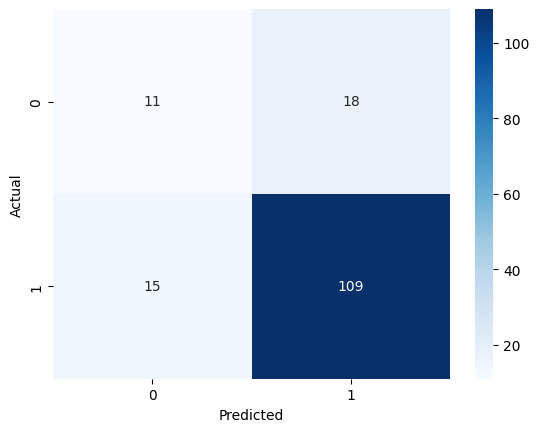

In [ ]:
# Step 7: Evaluate the best model on the training set
y_train_pred = model.predict(X_train, max_iter=best_iteration)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
#train_roc_auc = roc_auc_score(y_train, best_model.predict_proba(X_train), multi_class='ovr', average='weighted')
print(f'Accuracy on the training set: {train_accuracy * 100:.2f}%')
print(f'F1 score on the training set: {train_f1 * 100:.2f}%')
#print(f'ROC AUC on the training set: {train_roc_auc * 100:.2f}%')

# Step 8: Evaluate the best model on the validation set
# y_val_pred = model.predict(X_val, max_iter=best_iteration)
# val_accuracy = accuracy_score(y_val, y_val_pred)
# val_f1 = f1_score(y_val, y_val_pred, average='macro')
# #val_roc_auc = roc_auc_score(y_val, best_model.predict_proba(X_val), multi_class='ovr', average='weighted')
# print(f'Accuracy on the validation set: {val_accuracy * 100:.2f}%')
# print(f'F1 score on the validation set: {val_f1 * 100:.2f}%')
# #print(f'ROC AUC on the validation set: {val_roc_auc * 100:.2f}%')
# print(f'Classification report on the validation set:\n')
# print(classification_report(y_val, y_val_pred))

# Step 9: Evaluate the best model on the test set
y_test_pred = model.predict(X_test, max_iter=best_iteration)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')
#test_roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test), multi_class='ovr', average='weighted')
print(f'Accuracy on the test set: {test_accuracy * 100:.2f}%')
print(f'F1 score on the test set: {test_f1 * 100:.2f}%')
#print(f'ROC AUC on the test set: {test_roc_auc * 100:.2f}%')
print(f'Classification report on the test set:\n')
print(classification_report(y_test, y_test_pred))

# Step 10: Plot the confusion matrix
confusion_matrix = pd.crosstab(y_test, y_test_pred, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.show()


97


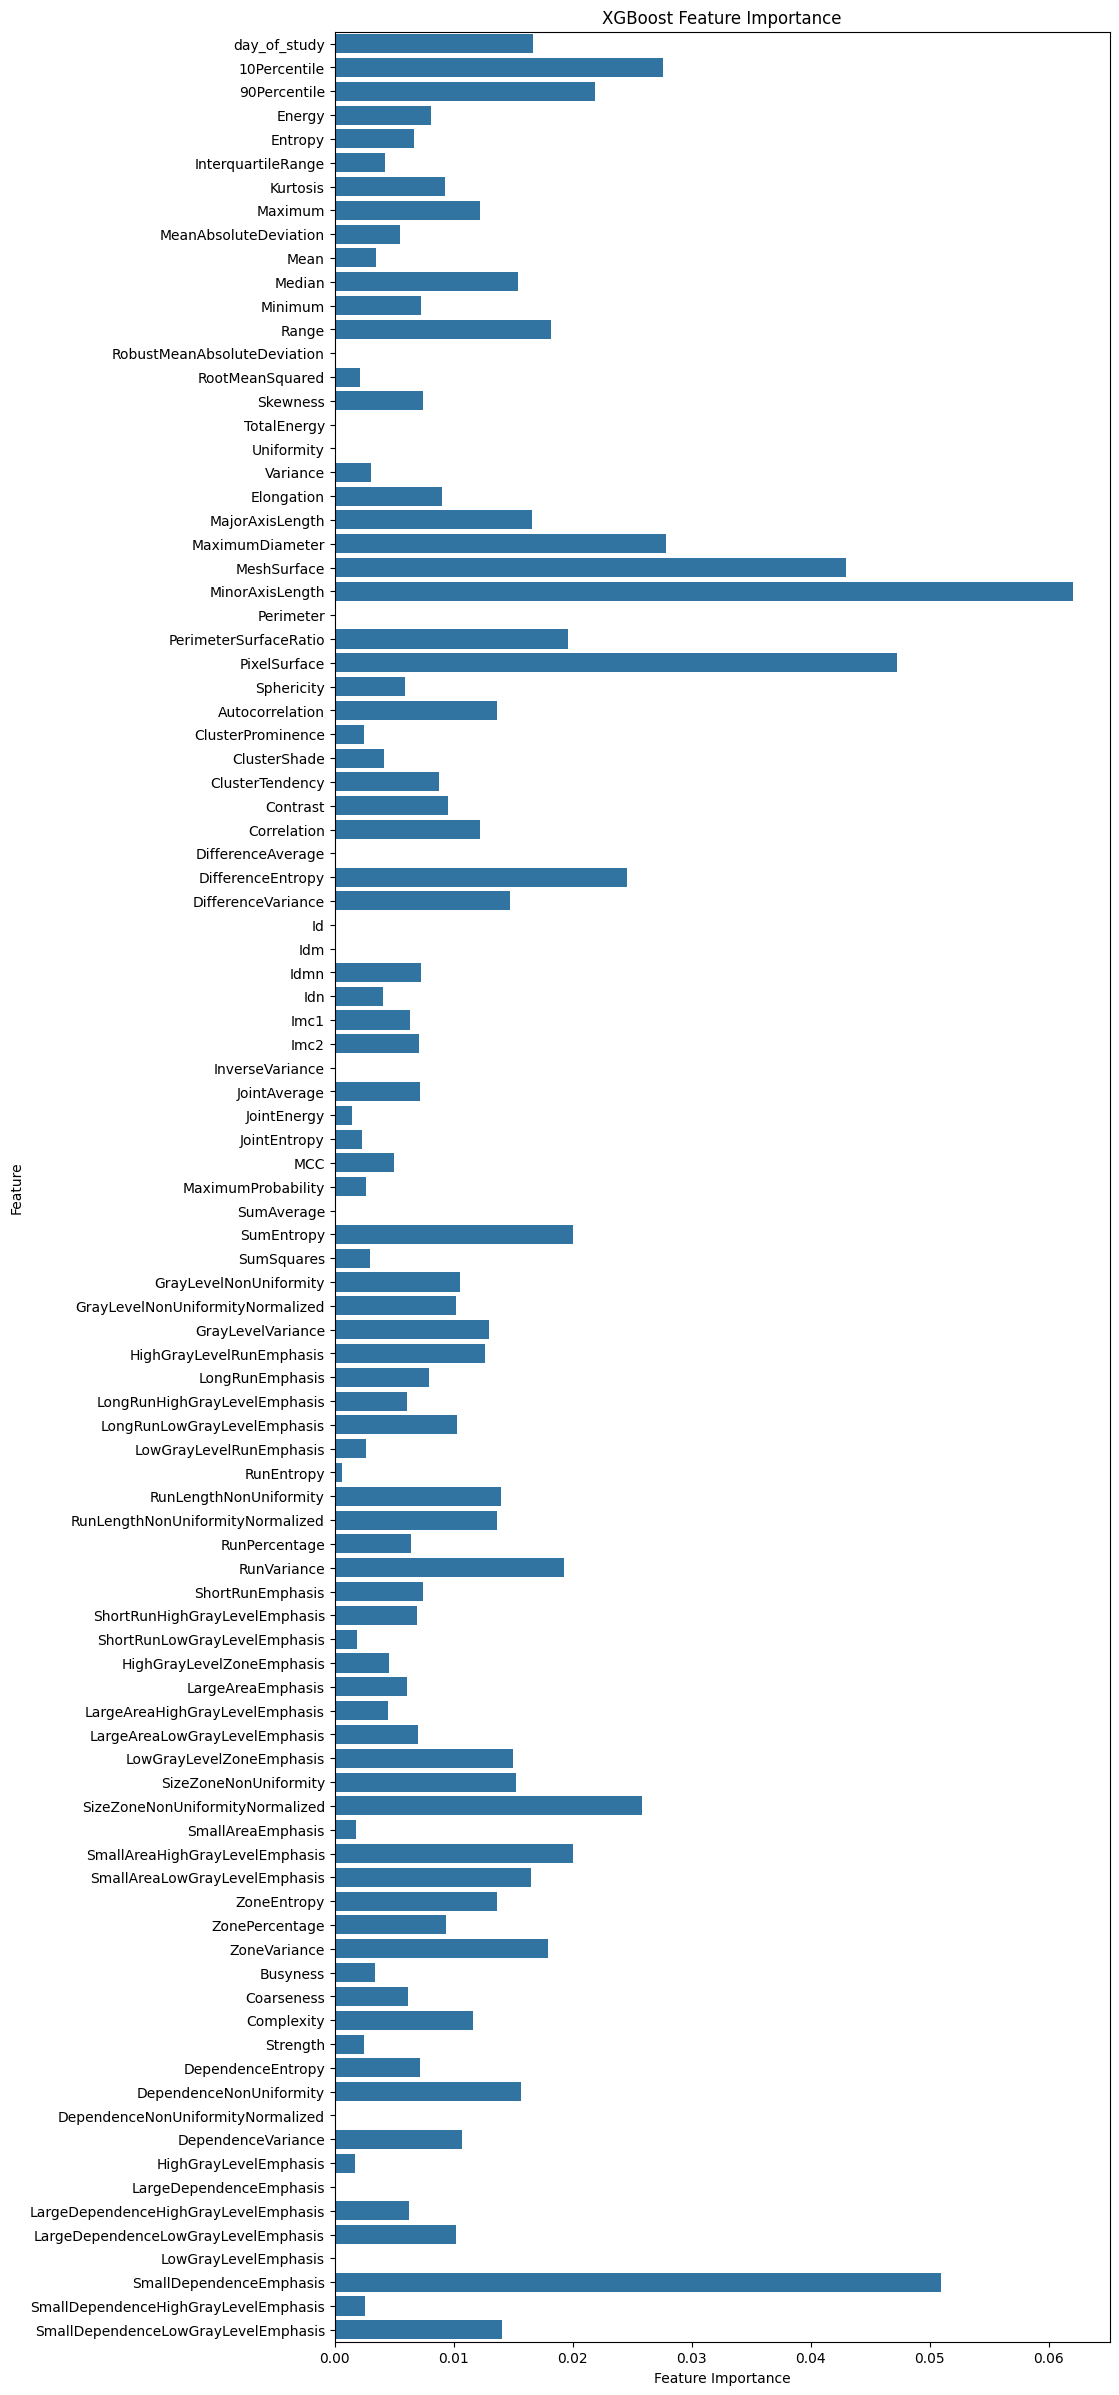

In [ ]:
importances_best_model = best_model.feature_importances_

# Plot the feature importance
print(len(importances_best_model))

plt.figure(figsize=(10, 30))
sns.barplot(x=importances_best_model, y=X.columns)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.show()

In [ ]:
# Number of top features to select (e.g., the 10 most important)
num_top_features = 10

# Select the N most important features based on feature importance from XGBoost
important_features_indices = np.argsort(importances_best_model)[-num_top_features:]  # The most important at the end
X_train_selected = X_train.iloc[:, important_features_indices]
X_val_selected = X_val.iloc[:, important_features_indices]
X_test_selected = X_test.iloc[:, important_features_indices]

# Display the selected features' names
print(X_train.columns[important_features_indices])

# Train the model using only the selected features
model_selected = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.2, random_state=42)  # You can reuse the best parameters
model_selected.fit(X_train_selected, y_train)

# Evaluate the model on the validation set
y_val_pred = model_selected.predict(X_val_selected)
print(f'Accuracy on the validation set: {accuracy_score(y_val, y_val_pred) * 100:.2f}%')
class_report = classification_report(y_val, y_val_pred)
print(f'Classification report on the validation set (selected features):\n{class_report}')

# Evaluate the model on the test set
y_test_pred = model_selected.predict(X_test_selected)
print(f'Accuracy on the test set: {accuracy_score(y_test, y_test_pred) * 100:.2f}%')
class_report = classification_report(y_test, y_test_pred)
print(f'Classification report on the test set (selected features):\n{class_report}')


Index(['SumEntropy', '90Percentile', 'DifferenceEntropy',
       'SizeZoneNonUniformityNormalized', '10Percentile', 'MaximumDiameter',
       'MeshSurface', 'PixelSurface', 'SmallDependenceEmphasis',
       'MinorAxisLength'],
      dtype='object')
Accuracy on the validation set: 84.62%
Classification report on the validation set (selected features):
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.91      0.91      0.91        33

    accuracy                           0.85        39
   macro avg       0.70      0.70      0.70        39
weighted avg       0.85      0.85      0.85        39

Accuracy on the test set: 80.52%
Classification report on the test set (selected features):
              precision    recall  f1-score   support

           0       0.62      0.29      0.40        17
           1       0.83      0.95      0.88        60

    accuracy                           0.81        77
   macro a

Accuracy on the validation set (selected features): 82.05%
              precision    recall  f1-score   support

           0       0.43      0.50      0.46         6
           1       0.91      0.88      0.89        33

    accuracy                           0.82        39
   macro avg       0.67      0.69      0.68        39
weighted avg       0.83      0.82      0.83        39

Accuracy on the test set (selected features): 84.42%
              precision    recall  f1-score   support

           0       0.63      0.71      0.67        17
           1       0.91      0.88      0.90        60

    accuracy                           0.84        77
   macro avg       0.77      0.79      0.78        77
weighted avg       0.85      0.84      0.85        77

10


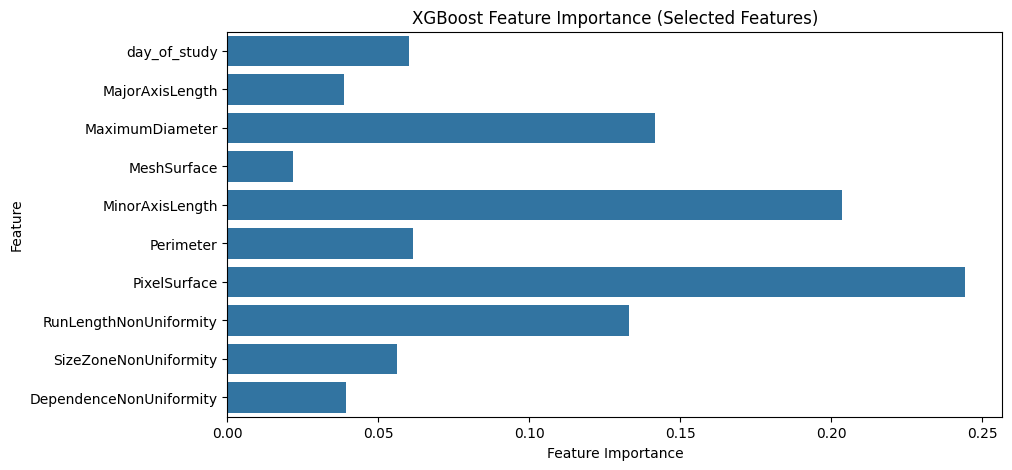

In [ ]:
# Apply feature selection

# Select the top 10 features
selector = SelectKBest(chi2, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

# Train a new XGBoost model on the selected features
model_selected = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.01, random_state=42 )# Best parameters found: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}
model_selected.fit(X_train_selected, y_train)

# Evaluate the model on the validation set
y_val_pred = model_selected.predict(X_val_selected)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set (selected features): {val_accuracy * 100:.2f}%')
print(classification_report(y_val, y_val_pred))

# Evaluate the model on the test set
y_test_pred = model_selected.predict(X_test_selected)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set (selected features): {test_accuracy * 100:.2f}%')
print(classification_report(y_test, y_test_pred))

# Plot the feature importance
print(len(model_selected.feature_importances_))

plt.figure(figsize=(10, 5))
sns.barplot(x=model_selected.feature_importances_, y=X.columns[selector.get_support()])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance (Selected Features)')
plt.show()

In [ ]:
# Train a SVM model
svm_model = svm.SVC()

# Define the parameters for the Grid Search
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Types of kernel
    'gamma': ['scale', 'auto']  # For non-linear kernels
}

# Configure the Grid Search with cross-validation
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, 
                           scoring='f1_macro', cv=10, n_jobs=-1)

# Fit the Grid Search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f'Best parameters found: {best_params}')

# Predict on the validation set
y_val_pred = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set: {val_accuracy * 100:.2f}%')
c_report = classification_report(y_val, y_val_pred)
print(f'Classification report on the validation set:\n{c_report}')

# Predict on the test set
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set: {test_accuracy * 100:.2f}%')
c_report = classification_report(y_test, y_test_pred)
print(f'Classification report on the test set:\n{c_report}')

Best parameters found: {'C': 100, 'gamma': 'auto', 'kernel': 'poly'}
Accuracy on the validation set: 64.10%
Classification report on the validation set:
              precision    recall  f1-score   support

           0       0.10      0.17      0.12         6
           1       0.83      0.73      0.77        33

    accuracy                           0.64        39
   macro avg       0.46      0.45      0.45        39
weighted avg       0.72      0.64      0.67        39

Accuracy on the test set: 77.92%
Classification report on the test set:
              precision    recall  f1-score   support

           0       0.50      0.53      0.51        17
           1       0.86      0.85      0.86        60

    accuracy                           0.78        77
   macro avg       0.68      0.69      0.69        77
weighted avg       0.78      0.78      0.78        77



In [ ]:
# Define the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Define the parameters for the Grid Search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2']  # The number of features to consider when looking for the best split
}

# Configure the Grid Search with cross-validation
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           scoring='accuracy', cv=10, n_jobs=-1)

# Fit the Grid Search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f'Best parameters found: {best_params}')

# Predict on the validation set
y_val_pred = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set: {val_accuracy * 100:.2f}%')
c_report = classification_report(y_val, y_val_pred)
print(f'Classification report on the validation set:\n{c_report}')

# Predict on the test set
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set: {test_accuracy * 100:.2f}%')
c_report = classification_report(y_test, y_test_pred)
print(f'Classification report on the test set:\n{c_report}')

Best parameters found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy on the validation set: 82.05%
Classification report on the validation set:
              precision    recall  f1-score   support

           0       0.43      0.50      0.46         6
           1       0.91      0.88      0.89        33

    accuracy                           0.82        39
   macro avg       0.67      0.69      0.68        39
weighted avg       0.83      0.82      0.83        39

Accuracy on the test set: 80.52%
Classification report on the test set:
              precision    recall  f1-score   support

           0       0.60      0.35      0.44        17
           1       0.84      0.93      0.88        60

    accuracy                           0.81        77
   macro avg       0.72      0.64      0.66        77
weighted avg       0.78      0.81      0.79        77

